In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('regression_data.csv')

In [ ]:
df.head()

,Age,6th_Stage,Differentiated,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Reginol_Node_Positive,Survival_Months
0,68.0,1,2,0,4.0,1,1,24.0,1,60
1,50.0,3,1,0,35.0,1,1,14.0,5,62
2,58.0,5,1,0,63.0,1,1,14.0,7,75
3,58.0,1,2,0,18.0,1,1,2.0,1,84
4,47.0,2,2,0,41.0,1,1,3.0,1,50


In [ ]:
X = df.drop(columns=['Survival_Months'])
y = df['Survival_Months']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3205, 9)
Test shape: (802, 9)


In [ ]:
regressor = DecisionTreeRegressor(random_state=42)

# Fit the regressor model
regressor.fit(X_train, y_train)

# Predict and evaluate
y_pred = regressor.predict(X_test)

# Print regression metrics
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))

Mean Squared Error: 1662.9043017456358
Mean Absolute Error: 27.352244389027433
R-squared: -0.49678621128281186


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Declare base learners
lr_model = LogisticRegression(C=1.0, penalty='l2', solver='liblinear', random_state=42)
nb_model = GaussianNB()

# Create the soft voting ensemble classifier
voting_clf = VotingClassifier(
    estimators=[('lr', lr_model), ('nb', nb_model)],
    voting='soft'
)

# Fit the ensemble model on training data
voting_clf.fit(X_train, y_train)


VotingClassifier(estimators=[('lr',
                              LogisticRegression(random_state=42,
                                                 solver='liblinear')),
                             ('nb', GaussianNB())],
                 voting='soft')

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

#  Logistic Regression
print("Logistic Regression")
# Fit the Logistic Regression model before predicting
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

from sklearn.metrics import mean_squared_error, r2_score
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lr))
print("R-squared:", r2_score(y_test, y_pred_lr))

# Naive Bayes
print("Naive Bayes")
# Fit the Naive Bayes model before predicting
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_nb))
print("R-squared:", r2_score(y_test, y_pred_nb))

Logistic Regression
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1
          10       0.50      1.00      0.67         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         2
          17       0.00      0.00      0.00         2
          18       0.00      0.00      0.00         2
          19       0.00      0.00      0.00         2
      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

# Make predictions
y_pred_ensemble = voting_clf.predict(X_test)
# y_proba_ensemble = voting_clf.predict_proba(X_test)[:, 1]  # Probability for class 1 - REMOVED


print("Voting Ensemble Classifier (LR + NB)")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble))
print("Classification Report:\n", classification_report(y_test, y_pred_ensemble))

from sklearn.metrics import mean_squared_error, r2_score
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_ensemble))
print("R-squared:", r2_score(y_test, y_pred_ensemble))

Voting Ensemble Classifier (LR + NB)
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 ...
 [5 4 0 ... 0 0 0]
 [4 4 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]]
Classification Report:
               precision    recall  f1-score   support

           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

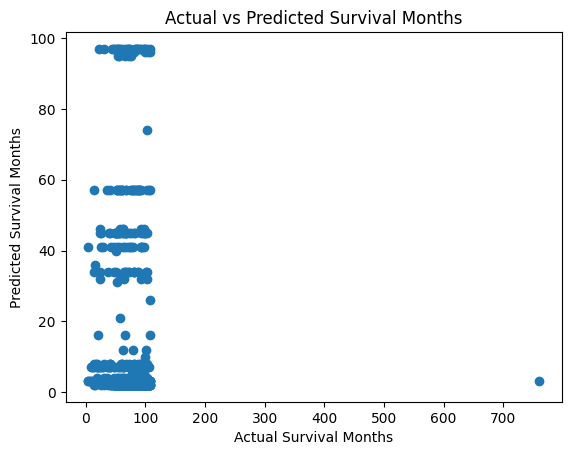

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_ensemble)
plt.xlabel("Actual Survival Months")
plt.ylabel("Predicted Survival Months")
plt.title("Actual vs Predicted Survival Months")
plt.show()

Model Training

Fully grown Decision tree DT1

In [ ]:
full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred_full = full_tree.predict(X_test)

mse_full = mean_squared_error(y_test, y_pred_full)
mae_full = mean_absolute_error(y_test, y_pred_full)
r2_full = r2_score(y_test, y_pred_full)

print("Fully Grown Decision Tree")
print(f"MSE:  {mse_full:.4f}")
print(f"MAE:  {mae_full:.4f}")
print(f"R Squared:   {r2_full:.4f}")

Fully Grown Decision Tree
MSE:  1662.9043
MAE:  27.3522
R Squared:   -0.4968


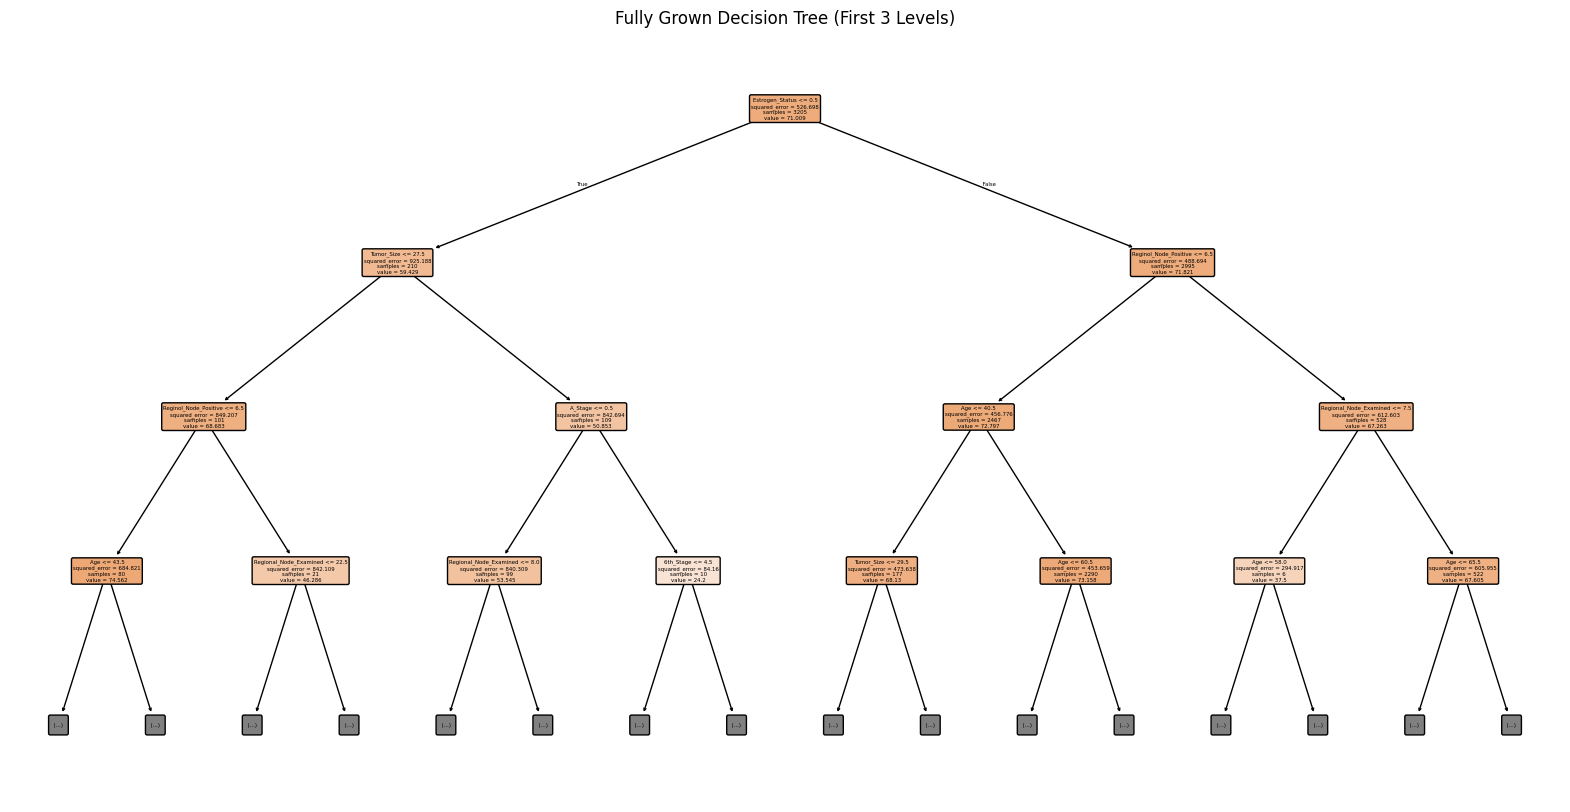

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(full_tree, filled=True, feature_names=X.columns, rounded=True, max_depth=3)  # max_depth=3 for clarity
plt.title("Fully Grown Decision Tree (First 3 Levels)")
plt.show()

Pruned Decision tree DT2

In [ ]:
pruned_tree = DecisionTreeRegressor(max_depth=4, random_state=42)
pruned_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [ ]:
y_pred_pruned = pruned_tree.predict(X_test)

mse_pruned = mean_squared_error(y_test, y_pred_pruned)
mae_pruned = mean_absolute_error(y_test, y_pred_pruned)
r2_pruned = r2_score(y_test, y_pred_pruned)

print("Pruned Decision Tree (Depth = 4)")
print(f"MSE:  {mse_pruned:.4f}")
print(f"MAE:  {mae_pruned:.4f}")
print(f"R Squared:   {r2_pruned:.4f}")

Pruned Decision Tree (Depth = 4)
MSE:  1117.1645
MAE:  19.6217
R Squared:   -0.0056


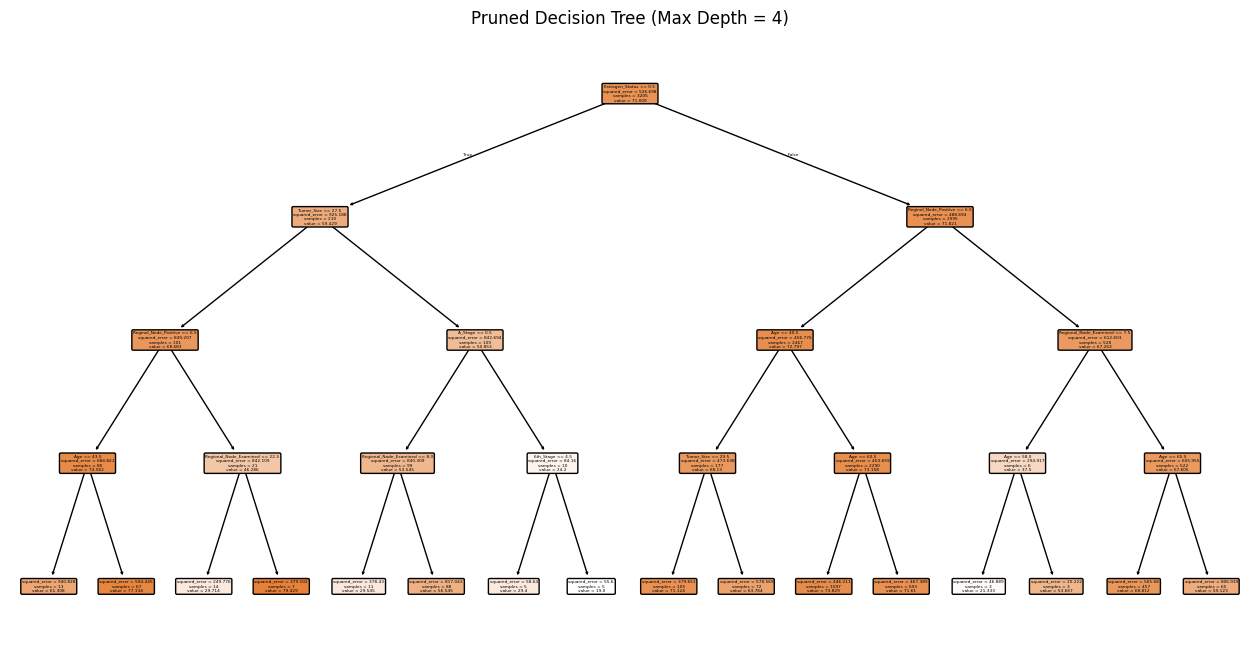

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(pruned_tree, filled=True, feature_names=X.columns, rounded=True)
plt.title("Pruned Decision Tree (Max Depth = 4)")
plt.show()

Predicted Survival Months for Patient B002565: 63.76


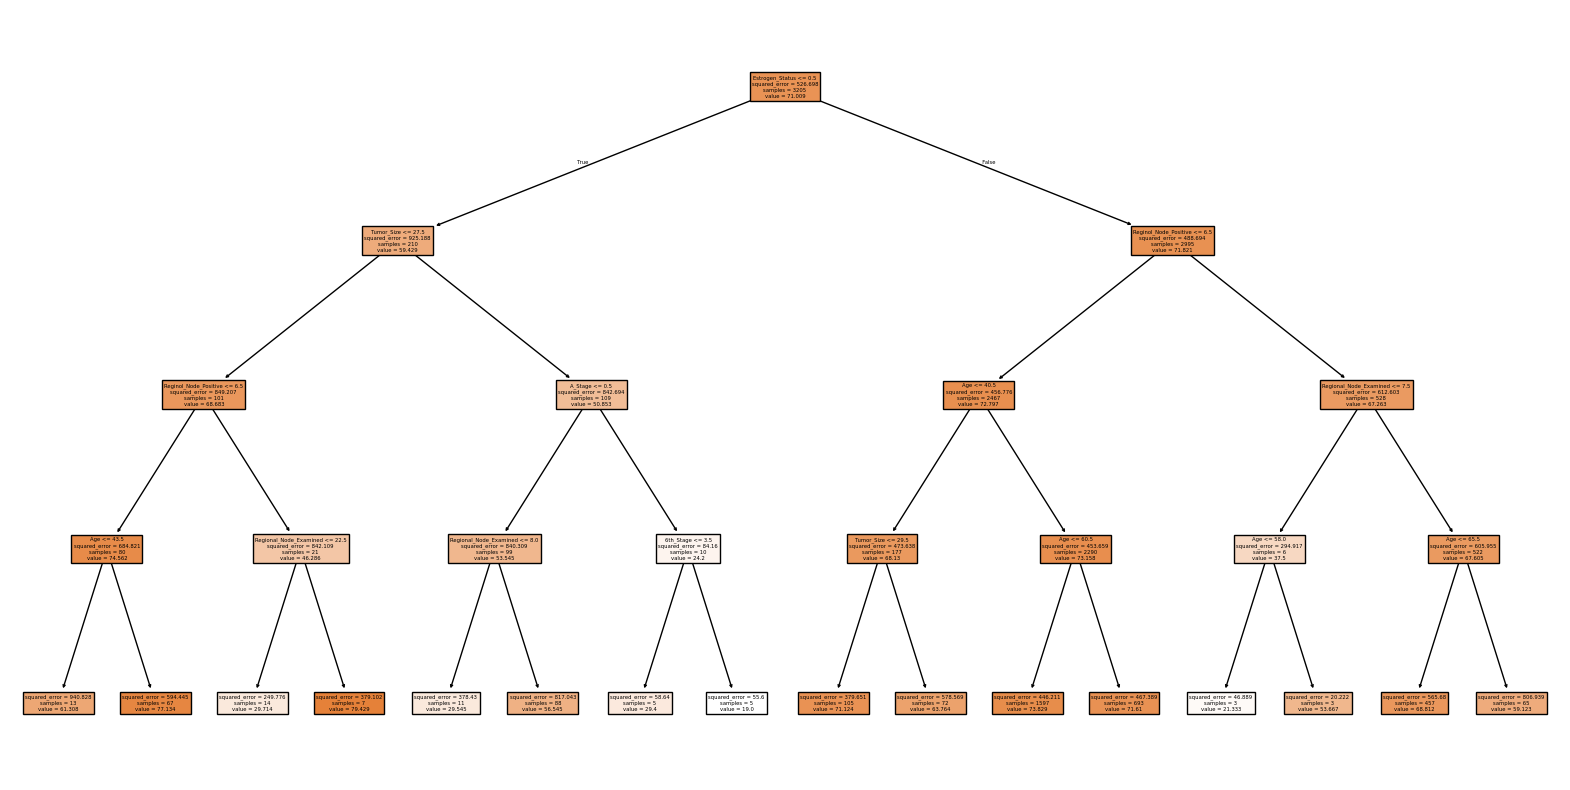

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables in training set
categorical_features = ['6th_Stage', 'Differentiated', 'A_Stage', 'Estrogen_Status', 'Progesterone_Status']
encoders = {feature: LabelEncoder().fit(X_train[feature]) for feature in categorical_features}

# Transform training data
for feature, encoder in encoders.items():
    X_train[feature] = encoder.transform(X_train[feature])

# Define and train the pruned decision tree model
pruned_tree = DecisionTreeRegressor(max_depth=4, random_state=42)
pruned_tree.fit(X_train, y_train)

# Define new patient data
patient_data = pd.DataFrame([{
    'Age': 29,
    '6th_Stage': 'IIIC',
    'Differentiated': 'Moderately differentiated',
    'A_Stage': 'Regional',
    'Tumor_Size': 41,
    'Estrogen_Status': 'Negative',
    'Progesterone_Status': 'Positive',
    'Regional_Node_Examined': 5,
    'Reginol_Node_Positive': 1
}])

# Apply same encoding to patient data using encoders fitted on X_train
# Transform categorical features in patient_data using the encoders
for feature, encoder in encoders.items():
    # Use try-except to handle potential unseen values in patient_data
    try:
        patient_data[feature] = encoder.transform(patient_data[feature])
    except ValueError:
        # If unseen value, handle it (e.g., impute with most frequent value)
        most_frequent_value = X_train[feature].mode()[0]
        print(f"Warning: Unseen value '{patient_data[feature].iloc[0]}' in '{feature}'. Imputing with '{most_frequent_value}'.")
        patient_data[feature] = most_frequent_value


# Ensure column order matches training data
patient_data = patient_data[X_train.columns]

# Predict using the trained model
predicted_months = pruned_tree.predict(patient_data)

# Output
print(f"Predicted Survival Months for Patient B002565: {predicted_months[0]:.2f}")

# Plot decision tree
plt.figure(figsize=(20, 10))
plot_tree(pruned_tree, feature_names=X_train.columns, filled=True)
plt.show()
